### CLIMATE STRESS ANALYSIS

In [4]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

___
ERA5

In [ ]:
path1 = 'DATA/ERA5/temperature2m.nc'
ds1 = xr.open_dataset(path1)
print(ds1)

<xarray.Dataset> Size: 93kB
Dimensions:     (valid_time: 420, latitude: 7, longitude: 7)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 1990-01-01 ... 2024-12-01
    expver      (valid_time) <U4 7kB ...
  * latitude    (latitude) float64 56B 14.5 14.25 14.0 13.75 13.5 13.25 13.0
  * longitude   (longitude) float64 56B 100.0 100.2 100.5 ... 101.0 101.2 101.5
    number      int64 8B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 82kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-27T04:18 GRIB to CDM+CF via cfgrib-0.9.1...


In [ ]:
path2 = 'DATA/ERA5/dewpointtemperature2m.nc'
ds2 = xr.open_dataset(path2)
print(ds2)

<xarray.Dataset> Size: 93kB
Dimensions:     (valid_time: 420, latitude: 7, longitude: 7)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 1990-01-01 ... 2024-12-01
    expver      (valid_time) <U4 7kB ...
  * latitude    (latitude) float64 56B 14.5 14.25 14.0 13.75 13.5 13.25 13.0
  * longitude   (longitude) float64 56B 100.0 100.2 100.5 ... 101.0 101.2 101.5
    number      int64 8B ...
Data variables:
    d2m         (valid_time, latitude, longitude) float32 82kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-27T04:26 GRIB to CDM+CF via cfgrib-0.9.1...


In [ ]:
path3 = 'DATA/ERA5/surfacepressure.nc'
ds3 = xr.open_dataset(path3)
print(ds3)

<xarray.Dataset> Size: 93kB
Dimensions:     (valid_time: 420, latitude: 7, longitude: 7)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 1990-01-01 ... 2024-12-01
    expver      (valid_time) <U4 7kB ...
  * latitude    (latitude) float64 56B 14.5 14.25 14.0 13.75 13.5 13.25 13.0
  * longitude   (longitude) float64 56B 100.0 100.2 100.5 ... 101.0 101.2 101.5
    number      int64 8B ...
Data variables:
    sp          (valid_time, latitude, longitude) float32 82kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-27T04:29 GRIB to CDM+CF via cfgrib-0.9.1...


In [ ]:
# 2M TEMPERATURE
# Convert from Kelvin to Celsius
t2m_celsius = ds['t2m'] - 273.15

# Spatial average over Bangkok region
t2m_mean = t2m_celsius.mean(dim=['latitude', 'longitude'])

print(f"Mean temperature: {float(t2m_mean.mean()):.1f} °C")
print(f"Max temperature: {float(t2m_mean.max()):.1f} °C")
print(f"Min temperature: {float(t2m_mean.min()):.1f} °C")

Mean temperature: 28.1 °C
Max temperature: 31.7 °C
Min temperature: 23.6 °C


In [9]:
# 2M DEWPOINT TEMPERATURE 
td_celsius = ds2['d2m'] - 273.15  # variable name is d2m in ERA5

td_mean = td_celsius.mean(dim=['latitude', 'longitude'])
print(f"Mean dewpoint: {float(td_mean.mean()):.1f} °C")
print(f"Max dewpoint: {float(td_mean.max()):.1f} °C")
print(f"Min dewpoint: {float(td_mean.min()):.1f} °C")

Mean dewpoint: 22.9 °C
Max dewpoint: 25.5 °C
Min dewpoint: 15.1 °C


In [10]:
# SURFACE PRESSURE
ps_hpa = ds3['sp'] / 100  # variable name is sp in ERA5, convert Pa to hPa

ps_mean = ps_hpa.mean(dim=['latitude', 'longitude'])
print(f"Mean pressure: {float(ps_mean.mean()):.1f} hPa")
print(f"Max pressure: {float(ps_mean.max()):.1f} hPa")
print(f"Min pressure: {float(ps_mean.min()):.1f} hPa")

Mean pressure: 1003.6 hPa
Max pressure: 1009.0 hPa
Min pressure: 999.9 hPa


___
CMIP6 PROJECTIONS

In [ ]:
# FILE CHECK HISTORICAL: VARIABLES, TIME DIMENSION, LAT/LONG COORDINATES, ETC
his = [
    'DATA/CMIP6/HIS-TAS-ACC/tas_Amon_ACCESS-CM2_historical_r1i1p1f1_gn_19900116-20141216.nc',      # HIS-TAS-ACC
    'DATA/CMIP6/HIS-TAS-MPI/tas_Amon_MPI-ESM1-2-LR_historical_r1i1p1f1_gn_19900116-20141216.nc',   # HIS-TAS-MPI
    'DATA/CMIP6/HIS-TAS-IPSL/tas_Amon_IPSL-CM6A-LR_historical_r1i1p1f1_gr_19900116-20141216.nc'     # HIS-TAS-IPSL
]

for f in his:
    print(f'{"="*50}')
    print(f'CEHCKING FILE: {f}')
    ds = xr.open_dataset(f)
    print(ds)
    print(ds.dims)
    print(ds.coords)

CEHCKING FILE: CMIP6/HIS-TAS-ACC/tas_Amon_ACCESS-CM2_historical_r1i1p1f1_gn_19900116-20141216.nc
<xarray.Dataset> Size: 10kB
Dimensions:    (time: 300, bnds: 2, lat: 2, lon: 1)
Coordinates:
  * time       (time) datetime64[ns] 2kB 1990-01-16T12:00:00 ... 2014-12-16T1...
  * lat        (lat) float64 16B 13.12 14.38
  * lon        (lon) float64 8B 100.3
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 5kB ...
    lat_bnds   (lat, bnds) float64 32B ...
    lon_bnds   (lon, bnds) float64 16B ...
    tas        (time, lat, lon) float32 2kB ...
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  0.0
    creation_date:          2019-11-08T06:41:46Z
    ...                     ...
    variable_id:            tas
    variant_label:          r1i1p1f1
    version:                v2

In [ ]:
# FILE CHECK SSPS2-4.5: VARIABLES, TIME DIMENSION, LAT/LONG COORDINATES, ETC
ssps2 = [
    'DATA/CMIP6/SSP2-TAS-ACC/tas_Amon_ACCESS-CM2_ssp245_r1i1p1f1_gn_20150116-20501216.nc',      # SSP2-TAS-ACC
    'DATA/CMIP6/SSP2-TAS-MPI/tas_Amon_MPI-ESM1-2-LR_ssp245_r1i1p1f1_gn_20150116-20501216.nc',   # SSP2-TAS-MPI
    'DATA/CMIP6/SSP2-TAS-IPSL/tas_Amon_IPSL-CM6A-LR_ssp245_r1i1p1f1_gr_20150116-20501216.nc'     # SSP2-TAS-IPSL
]

for f in ssps2:
    print(f'{"="*50}')
    print(f'CEHCKING FILE: {f}')
    ds = xr.open_dataset(f)
    print(f"Time range: {ds.time.values[0]} to {ds.time.values[-1]}")
    print(f"Dimensions: {dict(ds.dims)}")
    print(f"Variables: {list(ds.data_vars)}")

CEHCKING FILE: CMIP6/SSP2-TAS-ACC/tas_Amon_ACCESS-CM2_ssp245_r1i1p1f1_gn_20150116-20501216.nc
Time range: 2015-01-16T12:00:00.000000000 to 2050-12-16T12:00:00.000000000
Dimensions: {'time': 432, 'bnds': 2, 'lat': 1, 'lon': 1}
Variables: ['time_bnds', 'lat_bnds', 'lon_bnds', 'tas']
CEHCKING FILE: CMIP6/SSP2-TAS-MPI/tas_Amon_MPI-ESM1-2-LR_ssp245_r1i1p1f1_gn_20150116-20501216.nc


C:\Users\likre\AppData\Local\Temp\ipykernel_47160\4104946374.py:13: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Dimensions: {dict(ds.dims)}")


Time range: 2015-01-16T12:00:00.000000000 to 2050-12-16T12:00:00.000000000
Dimensions: {'time': 432, 'bnds': 2, 'lat': 1, 'lon': 1}
Variables: ['time_bnds', 'lat_bnds', 'lon_bnds', 'tas']
CEHCKING FILE: CMIP6/SSP2-TAS-IPSL/tas_Amon_IPSL-CM6A-LR_ssp245_r1i1p1f1_gr_20150116-20501216.nc
Time range: 2015-01-16T12:00:00.000000000 to 2050-12-16T12:00:00.000000000
Dimensions: {'time': 432, 'axis_nbounds': 2, 'lat': 1, 'lon': 1}
Variables: ['time_bounds', 'tas']


C:\Users\likre\AppData\Local\Temp\ipykernel_47160\4104946374.py:13: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Dimensions: {dict(ds.dims)}")
C:\Users\likre\AppData\Local\Temp\ipykernel_47160\4104946374.py:13: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Dimensions: {dict(ds.dims)}")


In [2]:
# FILE LISTINGS - CMIP6
for root, dirs, files in os.walk('CMIP6'):
    for file in files:
        if file.endswith('.nc'):
            print(os.path.join(root, file))

CMIP6\HIS-HUSS-ACC\huss_Amon_ACCESS-CM2_historical_r1i1p1f1_gn_19900116-20141216.nc
CMIP6\HIS-HUSS-IPSL\huss_Amon_IPSL-CM6A-LR_historical_r1i1p1f1_gr_19900116-20141216.nc
CMIP6\HIS-HUSS-MPI\huss_Amon_MPI-ESM1-2-LR_historical_r1i1p1f1_gn_19900116-20141216.nc
CMIP6\HIS-PS-ACC\ps_Amon_ACCESS-CM2_historical_r1i1p1f1_gn_19900116-20141216.nc
CMIP6\HIS-PS-IPSL\ps_Amon_IPSL-CM6A-LR_historical_r1i1p1f1_gr_19900116-20141216.nc
CMIP6\HIS-PS-MPI\ps_Amon_MPI-ESM1-2-LR_historical_r1i1p1f1_gn_19900116-20141216.nc
CMIP6\HIS-TAS-ACC\tas_Amon_ACCESS-CM2_historical_r1i1p1f1_gn_19900116-20141216.nc
CMIP6\HIS-TAS-IPSL\tas_Amon_IPSL-CM6A-LR_historical_r1i1p1f1_gr_19900116-20141216.nc
CMIP6\HIS-TAS-MPI\tas_Amon_MPI-ESM1-2-LR_historical_r1i1p1f1_gn_19900116-20141216.nc
CMIP6\SSP2-HUSS-ACC\huss_Amon_ACCESS-CM2_ssp245_r1i1p1f1_gn_20150116-20501216.nc
CMIP6\SSP2-HUSS-IPSL\huss_Amon_IPSL-CM6A-LR_ssp245_r1i1p1f1_gr_20150116-20501216.nc
CMIP6\SSP2-HUSS-MPI\huss_Amon_MPI-ESM1-2-LR_ssp245_r1i1p1f1_gn_20150116-2050121

In [ ]:
# FILE LISTINGS - ERA5
for root, dirs, files in os.walk('DATA/ERA5'):
    for file in files:
        if file.endswith('.nc'):
            print(os.path.join(root, file))

ERA5\dewpointtemperature2m.nc
ERA5\surfacepressure.nc
ERA5\temperature2m.nc


In [ ]:
# IMPORTS AND ALL FILE PATHS
# ERA5 paths
ERA5 = {
    't2m': r'DATA\ERA5\temperature2m.nc',
    'd2m': r'DATA\ERA5\dewpointtemperature2m.nc',
    'sp':  r'DATA\ERA5\surfacepressure.nc',
}

# CMIP6 paths
CMIP6 = {
    'ACCESS-CM2': {
        'historical': {
            'tas':  r'DATA\CMIP6\HIS-TAS-ACC\tas_Amon_ACCESS-CM2_historical_r1i1p1f1_gn_19900116-20141216.nc',
            'huss': r'DATA\CMIP6\HIS-HUSS-ACC\huss_Amon_ACCESS-CM2_historical_r1i1p1f1_gn_19900116-20141216.nc',
            'ps':   r'DATA\CMIP6\HIS-PS-ACC\ps_Amon_ACCESS-CM2_historical_r1i1p1f1_gn_19900116-20141216.nc',
        },
        'ssp245': {
            'tas':  r'DATA\CMIP6\SSP2-TAS-ACC\tas_Amon_ACCESS-CM2_ssp245_r1i1p1f1_gn_20150116-20501216.nc',
            'huss': r'DATA\CMIP6\SSP2-HUSS-ACC\huss_Amon_ACCESS-CM2_ssp245_r1i1p1f1_gn_20150116-20501216.nc',
            'ps':   r'DATA\CMIP6\SSP2-PS-ACC\ps_Amon_ACCESS-CM2_ssp245_r1i1p1f1_gn_20150116-20501216.nc',
        },
        'ssp585': {
            'tas':  r'DATA\CMIP6\SSP5-TAS-ACC\tas_Amon_ACCESS-CM2_ssp585_r1i1p1f1_gn_20150116-20501216.nc',
            'huss': r'DATA\CMIP6\SSP5-HUSS-ACC\huss_Amon_ACCESS-CM2_ssp585_r1i1p1f1_gn_20150116-20501216.nc',
            'ps':   r'DATA\CMIP6\SSP5-PS-ACC\ps_Amon_ACCESS-CM2_ssp585_r1i1p1f1_gn_20150116-20501216.nc',
        },
    },
    'IPSL-CM6A-LR': {
        'historical': {
            'tas':  r'DATA\CMIP6\HIS-TAS-IPSL\tas_Amon_IPSL-CM6A-LR_historical_r1i1p1f1_gr_19900116-20141216.nc',
            'huss': r'DATA\CMIP6\HIS-HUSS-IPSL\huss_Amon_IPSL-CM6A-LR_historical_r1i1p1f1_gr_19900116-20141216.nc',
            'ps':   r'DATA\CMIP6\HIS-PS-IPSL\ps_Amon_IPSL-CM6A-LR_historical_r1i1p1f1_gr_19900116-20141216.nc',
        },
        'ssp245': {
            'tas':  r'DATA\CMIP6\SSP2-TAS-IPSL\tas_Amon_IPSL-CM6A-LR_ssp245_r1i1p1f1_gr_20150116-20501216.nc',
            'huss': r'DATA\CMIP6\SSP2-HUSS-IPSL\huss_Amon_IPSL-CM6A-LR_ssp245_r1i1p1f1_gr_20150116-20501216.nc',
            'ps':   r'DATA\CMIP6\SSP2-PS-IPSL\ps_Amon_IPSL-CM6A-LR_ssp245_r1i1p1f1_gr_20150116-20501216.nc',
        },
        'ssp585': {
            'tas':  r'DATA\CMIP6\SSP5-TAS-IPSL\tas_Amon_IPSL-CM6A-LR_ssp585_r1i1p1f1_gr_20150116-20501216.nc',
            'huss': r'DATA\CMIP6\SSP5-HUSS-IPSL\huss_Amon_IPSL-CM6A-LR_ssp585_r1i1p1f1_gr_20150116-20501216.nc',
            'ps':   r'DATA\CMIP6\SSP5-PS-IPSL\ps_Amon_IPSL-CM6A-LR_ssp585_r1i1p1f1_gr_20150116-20501216.nc',
        },
    },
    'MPI-ESM1-2-LR': {
        'historical': {
            'tas':  r'DATA\CMIP6\HIS-TAS-MPI\tas_Amon_MPI-ESM1-2-LR_historical_r1i1p1f1_gn_19900116-20141216.nc',
            'huss': r'DATA\CMIP6\HIS-HUSS-MPI\huss_Amon_MPI-ESM1-2-LR_historical_r1i1p1f1_gn_19900116-20141216.nc',
            'ps':   r'DATA\CMIP6\HIS-PS-MPI\ps_Amon_MPI-ESM1-2-LR_historical_r1i1p1f1_gn_19900116-20141216.nc',
        },
        'ssp245': {
            'tas':  r'DATA\CMIP6\SSP2-TAS-MPI\tas_Amon_MPI-ESM1-2-LR_ssp245_r1i1p1f1_gn_20150116-20501216.nc',
            'huss': r'DATA\CMIP6\SSP2-HUSS-MPI\huss_Amon_MPI-ESM1-2-LR_ssp245_r1i1p1f1_gn_20150116-20501216.nc',
            'ps':   r'DATA\CMIP6\SSP2-PS-MPI\ps_Amon_MPI-ESM1-2-LR_ssp245_r1i1p1f1_gn_20150116-20501216.nc',
        },
        'ssp585': {
            'tas':  r'DATA\CMIP6\SSP5-TAS-MPI\tas_Amon_MPI-ESM1-2-LR_ssp585_r1i1p1f1_gn_20150116-20501216.nc',
            'huss': r'DATA\CMIP6\SSP5-HUSS-MPI\huss_Amon_MPI-ESM1-2-LR_ssp585_r1i1p1f1_gn_20150116-20501216.nc',
            'ps':   r'DATA\CMIP6\SSP5-PS-MPI\ps_Amon_MPI-ESM1-2-LR_ssp585_r1i1p1f1_gn_20150116-20501216.nc',
        },
    },
}

# Bounding box
LAT_MIN, LAT_MAX = 13.0, 14.5
LON_MIN, LON_MAX = 100.0, 101.5
print('SETUP COMPLETED - ALL PATHS DEFINED')

SETUP COMPLETED - ALL PATHS DEFINED


In [7]:
# OPEN AND INSPECT ERA5 FILES
# Open ERA5 files
dst2m = xr.open_dataset(ERA5['t2m'])
dsd2m = xr.open_dataset(ERA5['d2m'])
dssp  = xr.open_dataset(ERA5['sp'])

# Inspect each dataset
for label, ds in [('temperature2m', dst2m), ('dewpointtemperature2m', dsd2m), ('surfacepressure', dssp)]:
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(f"  Variables : {list(ds.data_vars)}")
    print(f"  Dimensions: {dict(ds.sizes)}")
    print(f"  Coords    : {list(ds.coords)}")
    
    # Time range
    if 'time' in ds.coords:
        print(f"  Time      : {str(ds.time.values[0])[:10]}  →  {str(ds.time.values[-1])[:10]}")
        print(f"  N timesteps: {ds.sizes['time']}")
    
    # Spatial coords — print first few values to see ranges and direction
    for dim in ['latitude', 'lat', 'longitude', 'lon']:
        if dim in ds.coords:
            vals = ds[dim].values
            print(f"  {dim:10s}: {vals[0]:.2f} → {vals[-1]:.2f}  (n={len(vals)})")
    
    # Units on each variable
    for var in ds.data_vars:
        attrs = ds[var].attrs
        units = attrs.get('units', 'no units attr')
        long_name = attrs.get('long_name', attrs.get('GRIB_name', '?'))
        print(f"  Var '{var}': units='{units}', long_name='{long_name}'")


  temperature2m
  Variables : ['t2m']
  Dimensions: {'valid_time': 420, 'latitude': 7, 'longitude': 7}
  Coords    : ['number', 'valid_time', 'latitude', 'longitude', 'expver']
  latitude  : 14.50 → 13.00  (n=7)
  longitude : 100.00 → 101.50  (n=7)
  Var 't2m': units='K', long_name='2 metre temperature'

  dewpointtemperature2m
  Variables : ['d2m']
  Dimensions: {'valid_time': 420, 'latitude': 7, 'longitude': 7}
  Coords    : ['number', 'valid_time', 'latitude', 'longitude', 'expver']
  latitude  : 14.50 → 13.00  (n=7)
  longitude : 100.00 → 101.50  (n=7)
  Var 'd2m': units='K', long_name='2 metre dewpoint temperature'

  surfacepressure
  Variables : ['sp']
  Dimensions: {'valid_time': 420, 'latitude': 7, 'longitude': 7}
  Coords    : ['number', 'valid_time', 'latitude', 'longitude', 'expver']
  latitude  : 14.50 → 13.00  (n=7)
  longitude : 100.00 → 101.50  (n=7)
  Var 'sp': units='Pa', long_name='Surface pressure'


In [14]:
# COMPUTE ERA5 HEAT INDEX
# Helper functions
def dew2rh(tas_c, td_c):
    """ERA5: dewpoint → relative humidity (%) via Magnus formula."""
    rh = 100 * (
        np.exp((17.625 * td_c) / (243.04 + td_c)) /
        np.exp((17.625 * tas_c) / (243.04 + tas_c))
    )
    return rh

def heatindex(t_c, rh):
    """Rothfusz Heat Index (°C). Returns NaN where T ≤ 27°C or RH ≤ 40%."""
    HI = (
        -8.78469475556
        + 1.61139411      * t_c
        + 2.33854883889   * rh
        - 0.14611605      * t_c * rh
        - 0.012308094     * t_c**2
        - 0.0164248277778 * rh**2
        + 0.002211732     * t_c**2 * rh
        + 0.00072546      * t_c    * rh**2
        - 0.000003582     * t_c**2 * rh**2
    )
    valid = (t_c > 27) & (rh > 40)
    return np.where(valid, HI, np.nan)

# Spatial average over bounding box - Latitude is descending (14.5 → 13.0) so slice high → low
t2m_spatial = dst2m['t2m'].sel(
    latitude=slice(LAT_MAX, LAT_MIN),
    longitude=slice(LON_MIN, LON_MAX)
).mean(dim=['latitude', 'longitude'])   # shape: (valid_time,)

d2m_spatial = dsd2m['d2m'].sel(
    latitude=slice(LAT_MAX, LAT_MIN),
    longitude=slice(LON_MIN, LON_MAX)
).mean(dim=['latitude', 'longitude'])

print(f'SPATIAL AVERAGE SHAPE: {t2m_spatial.shape}')
print(f'SAMPLE t2m VALUES (FIRST 3, K): {t2m_spatial.values[:3].round(2)}')

# Convert units
tas_c = t2m_spatial.values - 273.15    # K → °C
td_c  = d2m_spatial.values - 273.15   # K → °C

print(f'\nSAMPLE tas_c (FIRST 3, °C): {tas_c[:3].round(2)}')
print(f'SAMPLE td_c  (FIRST 3, °C): {td_c[:3].round(2)}')

# Relative humidity
rh = dew2rh(tas_c, td_c)
print(f'\nSAMPLE RH    (FIRST 3, %):  {rh[:3].round(1)}')
print(f'RH RANGE: {rh.min():.1f}% - {rh.max():.1f}%')

# Heat Index
hi = heatindex(tas_c, rh)
n_valid = np.sum(~np.isnan(hi))
n_total = len(hi)
print(f'\nHI VALID MONTHS: {n_valid} / {n_total}')
print(f'HI RANGE (°C): {np.nanmin(hi):.1f} - {np.nanmax(hi):.1f}')

# Build monthly Series, resample to annual
time_index = pd.DatetimeIndex(t2m_spatial['valid_time'].values)
era5_monthly = pd.Series(hi, index=time_index, name='HI_degC')
era5_annual  = era5_monthly.resample('YE').mean()
era5_annual.index = era5_annual.index.year   # integer year index

print(f'\nANNUAL RECORDS: {len(era5_annual)}  ({era5_annual.index[0]}-{era5_annual.index[-1]})')

# Summary table
print('\nERA5 ANNUAL MEAN HEAT INDEX (°C):')
print('─' * 30)
for yr, val in era5_annual.items():
    flag = ' ◄ MAX' if val == era5_annual.max() else (' ◄ MIN' if val == era5_annual.min() else '')
    print(f'  {yr}:  {val:.2f}{flag}')
print('─' * 30)
print(f'  OVERALL MEAN: {era5_annual.mean():.2f} °C')

SPATIAL AVERAGE SHAPE: (420,)
SAMPLE t2m VALUES (FIRST 3, K): [299.96 301.03 301.67]

SAMPLE tas_c (FIRST 3, °C): [26.81 27.88 28.52]
SAMPLE td_c  (FIRST 3, °C): [20.93 22.04 22.85]

SAMPLE RH    (FIRST 3, %):  [70.2 70.6 71.4]
RH RANGE: 59.1% - 84.0%

HI VALID MONTHS: 335 / 420
HI RANGE (°C): 28.4 - 39.4

ANNUAL RECORDS: 35  (1990-2024)

ERA5 ANNUAL MEAN HEAT INDEX (°C):
──────────────────────────────
  1990:  32.51
  1991:  32.17
  1992:  33.02
  1993:  32.38
  1994:  31.89
  1995:  32.79
  1996:  32.03
  1997:  31.99
  1998:  33.59
  1999:  31.62 ◄ MIN
  2000:  31.79
  2001:  32.28
  2002:  32.38
  2003:  32.66
  2004:  32.76
  2005:  33.09
  2006:  32.84
  2007:  32.37
  2008:  32.38
  2009:  32.66
  2010:  33.28
  2011:  31.87
  2012:  32.51
  2013:  32.64
  2014:  33.42
  2015:  33.37
  2016:  34.17
  2017:  32.83
  2018:  32.50
  2019:  33.79
  2020:  33.42
  2021:  32.83
  2022:  32.32
  2023:  33.44
  2024:  34.18 ◄ MAX
──────────────────────────────
  OVERALL MEAN: 32.73 °C


In [16]:
# INSPECT CMIP6 FILES — ACCESS-CM2 HISTORICAL (ONE REPRESENTATIVE CHECK)
ds_tas_acc  = xr.open_dataset(CMIP6['ACCESS-CM2']['historical']['tas'])
ds_huss_acc = xr.open_dataset(CMIP6['ACCESS-CM2']['historical']['huss'])
ds_ps_acc   = xr.open_dataset(CMIP6['ACCESS-CM2']['historical']['ps'])

for label, ds in [('tas', ds_tas_acc), ('huss', ds_huss_acc), ('ps', ds_ps_acc)]:
    print(f'\n{"="*55}')
    print(f'  ACCESS-CM2 historical — {label}')
    print(f'{"="*55}')
    print(f'  Variables : {list(ds.data_vars)}')
    print(f'  Dimensions: {dict(ds.sizes)}')
    print(f'  Coords    : {list(ds.coords)}')

    # Time — check all possible names
    for t_dim in ['time', 'valid_time']:
        if t_dim in ds.coords:
            print(f'  {t_dim:10s}: {str(ds[t_dim].values[0])[:10]}  →  {str(ds[t_dim].values[-1])[:10]}')

    # Spatial coords
    for dim in ['lat', 'lon', 'latitude', 'longitude']:
        if dim in ds.coords:
            vals = ds[dim].values
            print(f'  {dim:10s}: {vals[0]:.2f} → {vals[-1]:.2f}  (n={len(vals)})')

    # Variable metadata + sample — use first element of whatever dims exist
    for var in ds.data_vars:
        attrs = ds[var].attrs
        units     = attrs.get('units', 'no units attr')
        long_name = attrs.get('long_name', '?')
        print(f'  Var "{var}": units="{units}", long_name="{long_name}"')
        print(f'  Dims of "{var}": {ds[var].dims}')

        # Sample using actual dimension names from the variable
        first_slice = {dim: 0 for dim in ds[var].dims if dim not in ('lat', 'lon', 'latitude', 'longitude', 'bnds')}
        sample = ds[var].isel(**first_slice).values
        print(f'  Value range (first slice): {float(np.nanmin(sample)):.4f} – {float(np.nanmax(sample)):.4f}')


  ACCESS-CM2 historical — tas
  Variables : ['time_bnds', 'lat_bnds', 'lon_bnds', 'tas']
  Dimensions: {'time': 300, 'bnds': 2, 'lat': 2, 'lon': 1}
  Coords    : ['time', 'lat', 'lon', 'height']
  time      : 1990-01-16  →  2014-12-16
  lat       : 13.12 → 14.38  (n=2)
  lon       : 100.31 → 100.31  (n=1)
  Var "time_bnds": units="no units attr", long_name="?"
  Dims of "time_bnds": ('time', 'bnds')
  Value range (first slice): 631152000000000000.0000 – 633830400000000000.0000
  Var "lat_bnds": units="no units attr", long_name="?"
  Dims of "lat_bnds": ('lat', 'bnds')
  Value range (first slice): 12.5000 – 15.0000
  Var "lon_bnds": units="no units attr", long_name="?"
  Dims of "lon_bnds": ('lon', 'bnds')
  Value range (first slice): 99.3750 – 101.2500
  Var "tas": units="K", long_name="Near-Surface Air Temperature"
  Dims of "tas": ('time', 'lat', 'lon')
  Value range (first slice): 295.6804 – 296.7148

  ACCESS-CM2 historical — huss
  Variables : ['time_bnds', 'lat_bnds', 'lon_bnds'

In [18]:
# CMIP6 HEAT INDEX (ALL MODELS; ALL EXPERIMENTS)
# HELPER FUNCTION — CMIP6 specific humidity to relative humidity
def spechum2rh(huss, tas_k, ps_pa):
    """CMIP6: specific humidity + surface pressure → relative humidity (%)."""
    tas_c    = tas_k - 273.15
    e_sat    = 6.112 * np.exp((17.67 * tas_c) / (tas_c + 243.5))
    e_actual = huss * (ps_pa / 100) / (0.622 + 0.378 * huss)
    rh       = (e_actual / e_sat) * 100
    return rh

# PROCESS ONE MODEL+EXPERIMENT → annual HI Series
def process_cmip6(model, experiment):
    paths = CMIP6[model][experiment]

    ds_tas  = xr.open_dataset(paths['tas'])
    ds_huss = xr.open_dataset(paths['huss'])
    ds_ps   = xr.open_dataset(paths['ps'])

    # Spatial mean — lat ascending for CMIP6, so normal slice order
    tas  = ds_tas['tas'].sel(
        lat=slice(LAT_MIN, LAT_MAX),
        lon=slice(LON_MIN, LON_MAX)
    ).mean(dim=['lat', 'lon']).values          # K

    huss = ds_huss['huss'].sel(
        lat=slice(LAT_MIN, LAT_MAX),
        lon=slice(LON_MIN, LON_MAX)
    ).mean(dim=['lat', 'lon']).values          # kg/kg

    ps   = ds_ps['ps'].sel(
        lat=slice(LAT_MIN, LAT_MAX),
        lon=slice(LON_MIN, LON_MAX)
    ).mean(dim=['lat', 'lon']).values          # Pa

    rh = spechum2rh(huss, tas, ps)
    hi = heatindex(tas - 273.15, rh)

    time_index = pd.DatetimeIndex(ds_tas['time'].values)
    monthly    = pd.Series(hi, index=time_index)
    annual     = monthly.resample('YE').mean()
    annual.index = annual.index.year

    return annual

# PROCESS ALL MODELS × EXPERIMENTS
cmip6_results = {}

for model in CMIP6:
    cmip6_results[model] = {}
    print(f'\nMODEL: {model}')

    his = process_cmip6(model, 'historical')
    cmip6_results[model]['historical'] = his

    for ssp in ('ssp245', 'ssp585'):
        fut = process_cmip6(model, ssp)

        # Concatenate: historical up to 2014, SSP from 2015 onwards
        full = pd.concat([
            his[his.index <= 2014],
            fut[fut.index >= 2015]
        ])
        full.name = f'{model}_{ssp}'
        cmip6_results[model][ssp] = full

        print(f'  {ssp}: {len(full)} ANNUAL VALUES '
              f'({full.index.min()}–{full.index.max()}), '
              f'MEAN HI = {full.mean():.2f} °C, '
              f'2050 HI = {full.loc[2050]:.2f} °C')


MODEL: ACCESS-CM2
  ssp245: 61 ANNUAL VALUES (1990–2050), MEAN HI = 31.44 °C, 2050 HI = 32.02 °C
  ssp585: 61 ANNUAL VALUES (1990–2050), MEAN HI = 31.86 °C, 2050 HI = 34.29 °C

MODEL: IPSL-CM6A-LR
  ssp245: 61 ANNUAL VALUES (1990–2050), MEAN HI = 30.37 °C, 2050 HI = 31.66 °C
  ssp585: 61 ANNUAL VALUES (1990–2050), MEAN HI = 30.44 °C, 2050 HI = 31.65 °C

MODEL: MPI-ESM1-2-LR
  ssp245: 61 ANNUAL VALUES (1990–2050), MEAN HI = 31.16 °C, 2050 HI = 31.17 °C
  ssp585: 61 ANNUAL VALUES (1990–2050), MEAN HI = 31.00 °C, 2050 HI = 32.38 °C


In [19]:
# DIAGNOSTIC — print full annual timeseries for IPSL and MPI to check for flat/anomalous sections
for model in ['IPSL-CM6A-LR', 'MPI-ESM1-2-LR']:
    print(f'\n{"="*55}')
    print(f'  {model}')
    print(f'{"="*55}')
    for ssp in ('ssp245', 'ssp585'):
        s = cmip6_results[model][ssp]
        print(f'\n  {ssp}:')
        print(f'  {"YEAR":>6}  {"HI (°C)":>8}')
        print(f'  {"─"*18}')
        for yr, val in s.items():
            marker = ''
            if yr == 2014: marker = '  ← end of historical'
            if yr == 2015: marker = '  ← start of SSP'
            print(f'  {yr:>6}  {val:>8.2f}{marker}')
    
    # Also check how many grid points IPSL and MPI have in the bounding box
    print(f'\n  Grid point check:')
    ds_test = xr.open_dataset(CMIP6[model]['historical']['tas'])
    subset = ds_test['tas'].sel(
        lat=slice(LAT_MIN, LAT_MAX),
        lon=slice(LON_MIN, LON_MAX)
    )
    print(f'  lat values in box: {subset["lat"].values}')
    print(f'  lon values in box: {subset["lon"].values}')
    print(f'  Grid points: {subset.sizes["lat"]} lat × {subset.sizes["lon"]} lon')


  IPSL-CM6A-LR

  ssp245:
    YEAR   HI (°C)
  ──────────────────
    1990     28.11
    1991     28.57
    1992       nan
    1993     29.26
    1994     29.34
    1995     29.34
    1996       nan
    1997     29.19
    1998     29.73
    1999     29.77
    2000     30.56
    2001     29.59
    2002     30.95
    2003     30.00
    2004     27.99
    2005     30.26
    2006     30.50
    2007     30.01
    2008     29.97
    2009     30.27
    2010     30.99
    2011       nan
    2012     29.54
    2013     31.07
    2014     30.11  ← end of historical
    2015     30.17  ← start of SSP
    2016       nan
    2017     30.68
    2018     30.52
    2019     29.00
    2020     30.18
    2021     30.68
    2022     29.81
    2023     29.61
    2024     31.45
    2025     30.28
    2026     30.52
    2027     30.97
    2028     30.61
    2029     31.13
    2030     30.01
    2031     30.37
    2032     31.20
    2033     30.88
    2034     29.99
    2035     31.09
    2036     30.91
   

Diagnostic checks show:
* The NaNs are real (cool months below the HI validity threshold).
* The flat/coincidental 2050 values are not bugs.
* No data correction was needed.

Therefore, a rolling 5-year smooth is required to handle the scattered NaNs by averaging across neighbouring years, so isolated NaN years can get filled in naturally.

In [20]:
# ENSEMBLE — multi-model mean + uncertainty range
# Apply 5-year rolling mean to smooth interannual variability and fill isolated NaNs

MODELS = ['ACCESS-CM2', 'IPSL-CM6A-LR', 'MPI-ESM1-2-LR']
WINDOW = 5   # years

def build_ensemble(scenario):
    """
    Align all model timeseries for a given scenario,
    apply 5-year rolling mean, compute ensemble statistics.
    Returns a DataFrame indexed by year.
    """
    smoothed = {}
    for model in MODELS:
        s = cmip6_results[model][scenario].copy()
        # min_periods=3 — tolerate up to 2 NaN years in a 5-year window
        s_smooth = s.rolling(window=WINDOW, center=True, min_periods=3).mean()
        smoothed[model] = s_smooth

    df = pd.DataFrame(smoothed)
    df['ensemble_mean'] = df.mean(axis=1)
    df['ensemble_min']  = df.min(axis=1)
    df['ensemble_max']  = df.max(axis=1)
    return df

ens_ssp245 = build_ensemble('ssp245')
ens_ssp585 = build_ensemble('ssp585')

# Also smooth ERA5 for visual consistency
era5_smooth = era5_annual.rolling(window=WINDOW, center=True, min_periods=3).mean()

# Quick summary
print('ENSEMBLE SUMMARY')
print('─' * 50)
for label, ens in [('SSP2-4.5', ens_ssp245), ('SSP5-8.5', ens_ssp585)]:
    print(f'\n  {label}')
    for yr in [2030, 2040, 2050]:
        mean = ens.loc[yr, 'ensemble_mean']
        lo   = ens.loc[yr, 'ensemble_min']
        hi_  = ens.loc[yr, 'ensemble_max']
        print(f'    {yr}: {mean:.2f} °C  (range: {lo:.2f}–{hi_:.2f} °C)')

print(f'\n  ERA5 observed (smoothed):')
print(f'    1990: {era5_smooth.loc[1990]:.2f} °C')
print(f'    2024: {era5_smooth.loc[2024]:.2f} °C')

ENSEMBLE SUMMARY
──────────────────────────────────────────────────

  SSP2-4.5
    2030: 31.11 °C  (range: 30.66–31.57 °C)
    2040: 31.27 °C  (range: 30.90–31.61 °C)
    2050: 32.05 °C  (range: 31.66–32.39 °C)

  SSP5-8.5
    2030: 31.53 °C  (range: 30.71–32.20 °C)
    2040: 31.95 °C  (range: 31.35–32.70 °C)
    2050: 32.04 °C  (range: 30.86–33.39 °C)

  ERA5 observed (smoothed):
    1990: 32.56 °C
    2024: 33.31 °C


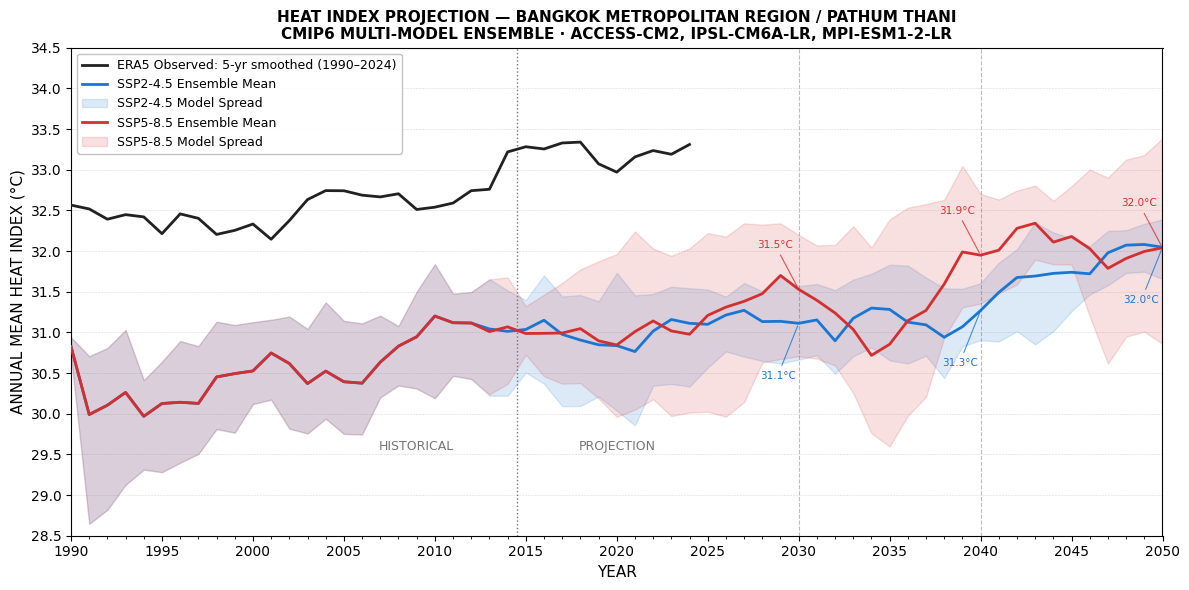

In [45]:
# VISUALISATION — Heat Index projections to 2050
fig, ax = plt.subplots(figsize=(12, 6))

# Colour palette
C_ERA5   = '#212121'      # near-black
C_SSP245 = '#1976D2'      # blue
C_SSP585 = '#D32F2F'      # red

# ERA5 observed (smoothed)
ax.plot(era5_smooth.index, era5_smooth.values, color=C_ERA5, linewidth=2.0, zorder=5, label='ERA5 Observed: 5-yr smoothed (1990–2024)')

# CMIP6 ensemble per scenario
for ssp, ens, color, label in [
    ('ssp245', ens_ssp245, C_SSP245, 'SSP2-4.5 Ensemble Mean'),
    ('ssp585', ens_ssp585, C_SSP585, 'SSP5-8.5 Ensemble Mean'),
]:
    years = ens.index
    ax.plot(years, ens['ensemble_mean'], color=color, linewidth=2.0, zorder=4, label=label)

    ax.fill_between(years,
                    ens['ensemble_min'], ens['ensemble_max'],
                    color=color, alpha=0.15, zorder=2,
                    label=f'{"SSP2-4.5" if ssp == "ssp245" else "SSP5-8.5"} Model Spread')

# Historical / projection divider
ax.axvline(2014.5, color='#757575', linewidth=1.0, linestyle=':', zorder=3)
ax.text(2009.0, 29.55, 'HISTORICAL', fontsize=9, color='#757575', ha='center')
ax.text(2020.0, 29.55, 'PROJECTION', fontsize=9, color='#757575', ha='center')

# Milestone vertical lines and annotations
# Offsets: (x_points, y_points) — tuned per scenario to avoid line overlap
OFFSETS = {
    'ssp245': (-28, -40),    # blue — nudge left and below
    'ssp585': (-30, 30),    # red  — nudge left and above
}

for yr in [2030, 2040, 2050]:
    ax.axvline(yr, color='#BDBDBD', linewidth=0.8, linestyle='--', zorder=1)
    for ssp, ens, color in [
        ('ssp245', ens_ssp245, C_SSP245),
        ('ssp585', ens_ssp585, C_SSP585),
    ]:
        val = ens.loc[yr, 'ensemble_mean']
        ox, oy = OFFSETS[ssp]
        ax.annotate(f'{val:.1f}°C',
                    xy=(yr, val),
                    xytext=(ox, oy),
                    textcoords='offset points',
                    fontsize=7.5, color=color, zorder=6,
                    arrowprops=dict(arrowstyle='-', color=color, lw=0.8, alpha=0.8))

# Axes formatting
ax.set_xlim(1990, 2050)
ax.set_ylim(28.5, 34.5)
ax.set_xlabel('YEAR', fontsize=11)
ax.set_ylabel('ANNUAL MEAN HEAT INDEX (°C)', fontsize=11)
ax.set_title(
    'HEAT INDEX PROJECTION — BANGKOK METROPOLITAN REGION / PATHUM THANI\n'
    'CMIP6 MULTI-MODEL ENSEMBLE · ACCESS-CM2, IPSL-CM6A-LR, MPI-ESM1-2-LR',
    fontsize=11, fontweight='bold'
)
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax.grid(axis='y', linestyle='--', linewidth=0.4, alpha=0.5)
ax.tick_params(axis='both', labelsize=10)

# Legend
ax.legend(fontsize=9, loc='upper left', framealpha=0.9, edgecolor='#BDBDBD')
plt.tight_layout()
# plt.savefig('heat_index_projections.png', dpi=300, bbox_inches='tight')
# print('Figure saved → heat_index_projections.png')
plt.show();


In [48]:
# EXPORT PROCESSED DATA TO CSV
os.makedirs('OUTPUTS', exist_ok=True)

# ERA5 annual Heat Index (unsmoothed — preserve raw annual values)
era5_annual.to_csv('OUTPUTS/era5_annual_hi.csv', header=['HI_degC'])
print('Saved: OUTPUTS/era5_annual_hi.csv')

# ERA5 smoothed (5-yr rolling)
era5_smooth.to_csv('OUTPUTS/era5_smooth_hi.csv', header=['HI_degC_smooth'])
print('Saved: OUTPUTS/era5_smooth_hi.csv')

# Individual model timeseries — all scenarios
for model in MODELS:
    for ssp in ('ssp245', 'ssp585'):
        s = cmip6_results[model][ssp]
        fname = f"OUTPUTS/cmip6_{model.replace('-','_')}_{ssp}_annual_hi.csv"
        s.to_csv(fname, header=['HI_degC'])
        print(f'Saved: {fname}')

# Ensemble DataFrames — SSP2-4.5 and SSP5-8.5
ens_ssp245.to_csv('OUTPUTS/ensemble_ssp245_hi.csv')
print('Saved: OUTPUTS/ensemble_ssp245_hi.csv')

ens_ssp585.to_csv('OUTPUTS/ensemble_ssp585_hi.csv')
print('Saved: OUTPUTS/ensemble_ssp585_hi.csv')

print('\nAll exports complete.')
print(f'Files in OUTPUTS/:')
for f in sorted(os.listdir('OUTPUTS')):
    print(f'  {f}')

Saved: OUTPUTS/era5_annual_hi.csv
Saved: OUTPUTS/era5_smooth_hi.csv
Saved: OUTPUTS/cmip6_ACCESS_CM2_ssp245_annual_hi.csv
Saved: OUTPUTS/cmip6_ACCESS_CM2_ssp585_annual_hi.csv
Saved: OUTPUTS/cmip6_IPSL_CM6A_LR_ssp245_annual_hi.csv
Saved: OUTPUTS/cmip6_IPSL_CM6A_LR_ssp585_annual_hi.csv
Saved: OUTPUTS/cmip6_MPI_ESM1_2_LR_ssp245_annual_hi.csv
Saved: OUTPUTS/cmip6_MPI_ESM1_2_LR_ssp585_annual_hi.csv
Saved: OUTPUTS/ensemble_ssp245_hi.csv
Saved: OUTPUTS/ensemble_ssp585_hi.csv

All exports complete.
Files in OUTPUTS/:
  cmip6_ACCESS_CM2_ssp245_annual_hi.csv
  cmip6_ACCESS_CM2_ssp585_annual_hi.csv
  cmip6_IPSL_CM6A_LR_ssp245_annual_hi.csv
  cmip6_IPSL_CM6A_LR_ssp585_annual_hi.csv
  cmip6_MPI_ESM1_2_LR_ssp245_annual_hi.csv
  cmip6_MPI_ESM1_2_LR_ssp585_annual_hi.csv
  ensemble_ssp245_hi.csv
  ensemble_ssp585_hi.csv
  era5_annual_hi.csv
  era5_smooth_hi.csv


___
**END**